# Lab Final (Task-2)

## Name: Tasrif Nur Himel
## ID: 221-35-1078

### Course Code: DS422
### Section: B1
### Batch: 37

### Load dataset

### Dataset Acquisition and	Data Loading

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
print(tf.__version__)

2.19.0


In [ ]:
(x_train,y_train) , (x_test,y_test) = keras.datasets.mnist.load_data()

### Data Exploration

In [ ]:
print(len(x_train))
print(len(x_test))

60000
10000


### Data Preprocessing

In [ ]:
X_train_img = x_train.copy()
X_test_img  = x_test.copy()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.utils import resample

np.random.seed(42)


In [ ]:
X_train = x_train.astype("float32") / 255.0
X_test  = x_test.astype("float32")  / 255.0

In [ ]:
X_train_flat = X_train.reshape(len(X_train), 28*28)
X_test_flat  = X_test.reshape(len(X_test), 28*28)

In [ ]:
import pandas as pd

pixel_cols = [f"pixel{i}" for i in range(28*28)]

train_df = pd.DataFrame(X_train_flat, columns=pixel_cols)
train_df.insert(0, 'label', y_train.astype(int))

test_df = pd.DataFrame(X_test_flat, columns=pixel_cols)
test_df.insert(0, 'label', y_test.astype(int))

train_df.shape, test_df.shape


((60000, 785), (10000, 785))

In [ ]:
print("Train samples:", len(train_df), " | Test samples:", len(test_df))
print("Features per sample:", train_df.shape[1] - 1)

classes = sorted(train_df['label'].unique().tolist())
print("Target classes:", classes)

print("\nTrain class counts:")
print(train_df['label'].value_counts().sort_index())

print("\nTest class counts:")
print(test_df['label'].value_counts().sort_index())


Train samples: 60000  | Test samples: 10000
Features per sample: 784
Target classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Train class counts:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

Test class counts:
label
0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
Name: count, dtype: int64


### Visualization

In [ ]:
X_train_img[0].shape, y_train[0]

((28, 28), np.uint8(5))

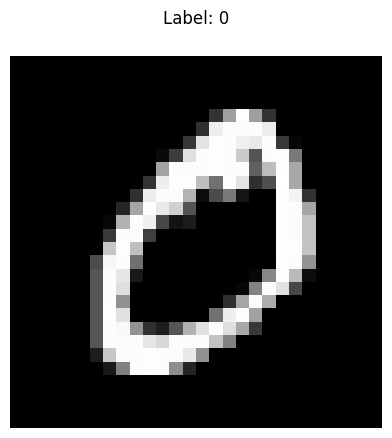

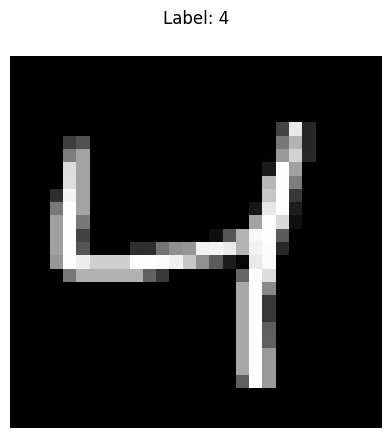

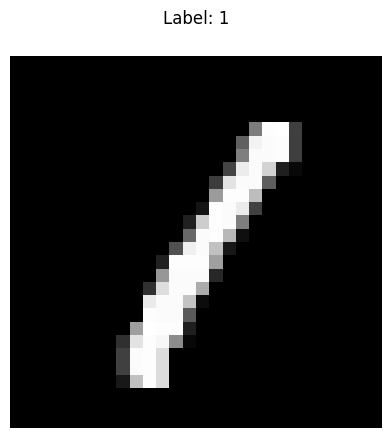

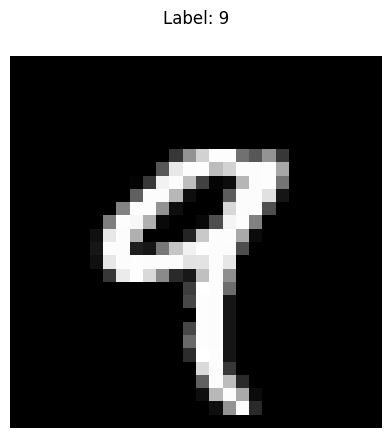

In [ ]:
for i in range(1, 5):
    plt.matshow(X_train_img[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()

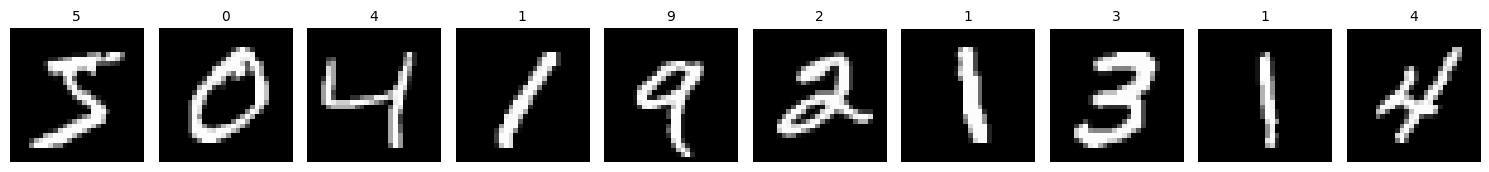

In [ ]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(X_train_img[i], cmap='gray')
    axes[i].set_title(str(y_train[i]), fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()


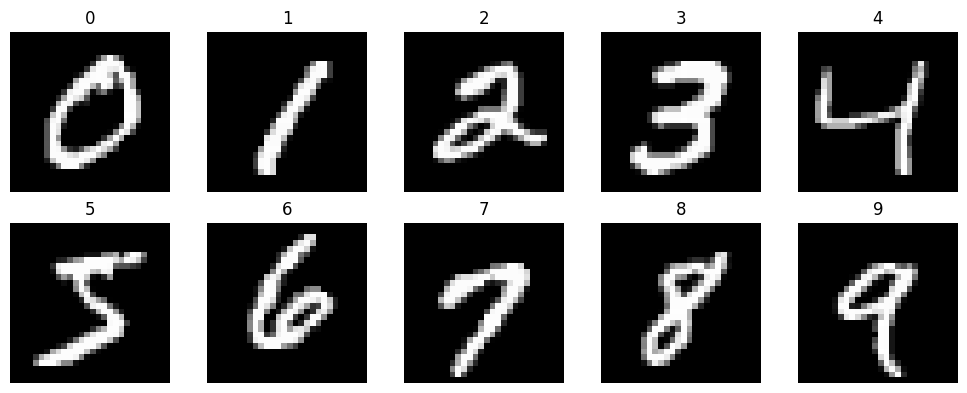

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for d in range(10):
    idx = np.where(y_train == d)[0][0]
    axes[d].imshow(X_train_img[idx], cmap='gray')
    axes[d].set_title(f"{d}")
    axes[d].axis('off')

plt.tight_layout()
plt.show()

## Model Training

### Logistic Regression (baseline)

Logistic Regression — Training
Accuracy:  0.9382
Precision: 0.9381
Recall:    0.9382
F1-score:  0.9381
-----------------------------------
Logistic Regression — Test
Accuracy:  0.9268
Precision: 0.9266
Recall:    0.9268
F1-score:  0.9266


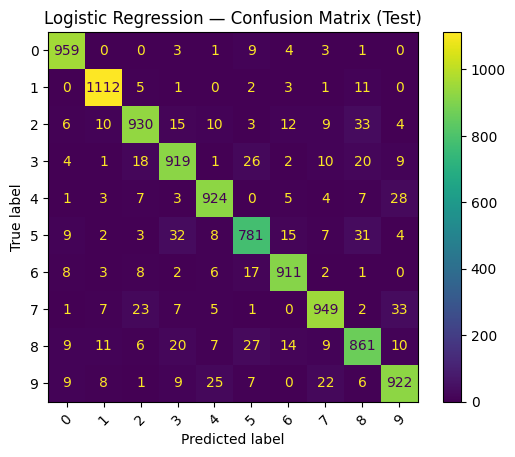

In [ ]:

lr = LogisticRegression(solver='lbfgs', max_iter=200, n_jobs=-1)
lr.fit(X_train_flat, y_train)

y_tr_pred = lr.predict(X_train_flat)
tr_acc  = accuracy_score(y_train, y_tr_pred)
tr_prec = precision_score(y_train, y_tr_pred, average='weighted', zero_division=0)
tr_rec  = recall_score(y_train, y_tr_pred, average='weighted', zero_division=0)
tr_f1   = f1_score(y_train, y_tr_pred, average='weighted')

print("Logistic Regression — Training")
print(f"Accuracy:  {tr_acc:.4f}")
print(f"Precision: {tr_prec:.4f}")
print(f"Recall:    {tr_rec:.4f}")
print(f"F1-score:  {tr_f1:.4f}")
print("-"*35)

y_te_pred = lr.predict(X_test_flat)
te_acc  = accuracy_score(y_test, y_te_pred)
te_prec = precision_score(y_test, y_te_pred, average='weighted', zero_division=0)
te_rec  = recall_score(y_test, y_te_pred, average='weighted', zero_division=0)
te_f1   = f1_score(y_test, y_te_pred, average='weighted')

print("Logistic Regression — Test")
print(f"Accuracy:  {te_acc:.4f}")
print(f"Precision: {te_prec:.4f}")
print(f"Recall:    {te_rec:.4f}")
print(f"F1-score:  {te_f1:.4f}")

cm = confusion_matrix(y_test, y_te_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
plt.title("Logistic Regression — Confusion Matrix (Test)")
plt.show()

### SVM (RBF) baseline

SVM (RBF) — Training
Accuracy:  0.9899
Precision: 0.9899
Recall:    0.9899
F1-score:  0.9899
-----------------------------------
SVM (RBF) — Test
Accuracy:  0.9792
Precision: 0.9792
Recall:    0.9792
F1-score:  0.9792


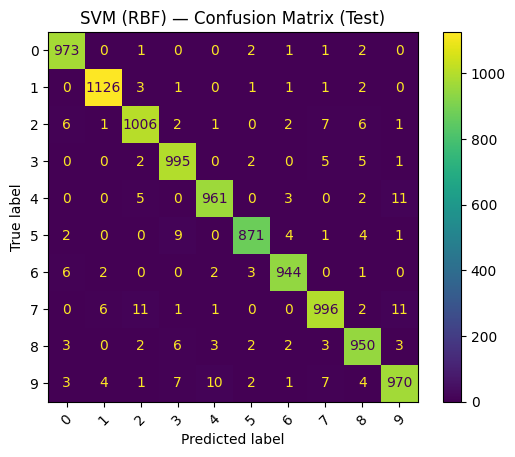

In [ ]:

Xtr, ytr = X_train_flat, y_train

svm = SVC(kernel='rbf', gamma='scale', C=1.0)
svm.fit(Xtr, ytr)

y_tr_pred = svm.predict(Xtr)
tr_acc  = accuracy_score(ytr, y_tr_pred)
tr_prec = precision_score(ytr, y_tr_pred, average='weighted', zero_division=0)
tr_rec  = recall_score(ytr, y_tr_pred, average='weighted', zero_division=0)
tr_f1   = f1_score(ytr, y_tr_pred, average='weighted')

print("SVM (RBF) — Training")
print(f"Accuracy:  {tr_acc:.4f}")
print(f"Precision: {tr_prec:.4f}")
print(f"Recall:    {tr_rec:.4f}")
print(f"F1-score:  {tr_f1:.4f}")
print("-"*35)

y_te_pred = svm.predict(X_test_flat)
te_acc  = accuracy_score(y_test, y_te_pred)
te_prec = precision_score(y_test, y_te_pred, average='weighted', zero_division=0)
te_rec  = recall_score(y_test, y_te_pred, average='weighted', zero_division=0)
te_f1   = f1_score(y_test, y_te_pred, average='weighted')

print("SVM (RBF) — Test")
print(f"Accuracy:  {te_acc:.4f}")
print(f"Precision: {te_prec:.4f}")
print(f"Recall:    {te_rec:.4f}")
print(f"F1-score:  {te_f1:.4f}")

cm = confusion_matrix(y_test, y_te_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
plt.title("SVM (RBF) — Confusion Matrix (Test)")
plt.show()


Decision Tree — Training
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
-----------------------------------
Decision Tree — Test
Accuracy:  0.8754
Precision: 0.8753
Recall:    0.8754
F1-score:  0.8753


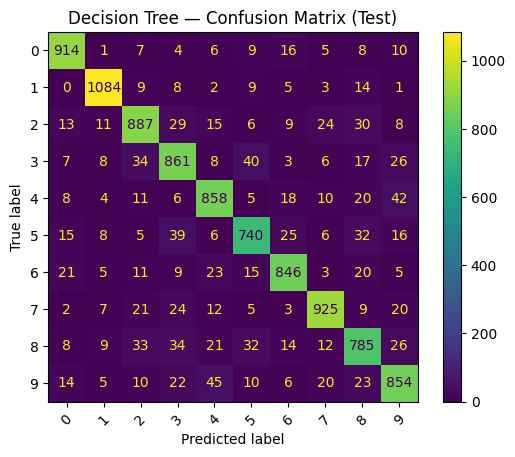

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_flat, y_train)

y_tr_pred = dt.predict(X_train_flat)
tr_acc  = accuracy_score(y_train, y_tr_pred)
tr_prec = precision_score(y_train, y_tr_pred, average='weighted', zero_division=0)
tr_rec  = recall_score(y_train, y_tr_pred, average='weighted', zero_division=0)
tr_f1   = f1_score(y_train, y_tr_pred, average='weighted')

print("Decision Tree — Training")
print(f"Accuracy:  {tr_acc:.4f}")
print(f"Precision: {tr_prec:.4f}")
print(f"Recall:    {tr_rec:.4f}")
print(f"F1-score:  {tr_f1:.4f}")
print("-"*35)

y_te_pred = dt.predict(X_test_flat)
te_acc  = accuracy_score(y_test, y_te_pred)
te_prec = precision_score(y_test, y_te_pred, average='weighted', zero_division=0)
te_rec  = recall_score(y_test, y_te_pred, average='weighted', zero_division=0)
te_f1   = f1_score(y_test, y_te_pred, average='weighted')

print("Decision Tree — Test")
print(f"Accuracy:  {te_acc:.4f}")
print(f"Precision: {te_prec:.4f}")
print(f"Recall:    {te_rec:.4f}")
print(f"F1-score:  {te_f1:.4f}")

cm = confusion_matrix(y_test, y_te_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
plt.title("Decision Tree — Confusion Matrix (Test)")
plt.show()


### Hyperparameter Optimization

### GridSearchCV for Logistic Regression

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (LR): {'C': 0.1, 'max_iter': 300, 'solver': 'lbfgs'}
Best CV accuracy: 0.9194

Tuned LR — Training
Accuracy: 0.9324
Precision: 0.9322
Recall: 0.9324
F1-score: 0.9323

Tuned LR — Test
Accuracy: 0.9259
Precision: 0.9258
Recall: 0.9259
F1-score: 0.9257


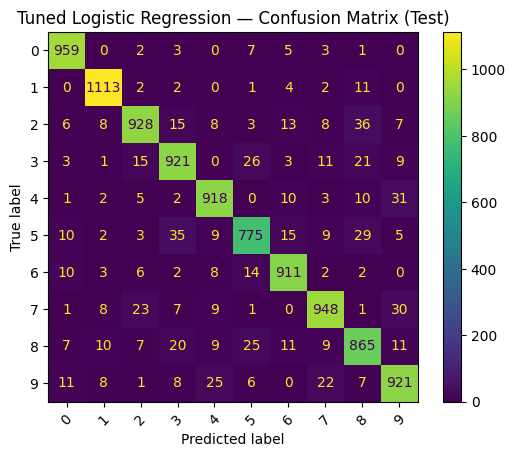

In [ ]:
log_grid = {
    'C': [0.1, 1.0, 3.0],
    'solver': ['lbfgs'],
    'max_iter': [300]
}

gs_lr = GridSearchCV(
    estimator=LogisticRegression(n_jobs=-1),
    param_grid=log_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

gs_lr.fit(X_train_flat, y_train)
print("Best params (LR):", gs_lr.best_params_)
print("Best CV accuracy:", gs_lr.best_score_)

lr_best = gs_lr.best_estimator_

y_tr_pred = lr_best.predict(X_train_flat)
print("\nTuned LR — Training")
print("Accuracy:", round(accuracy_score(y_train, y_tr_pred), 4))
print("Precision:", round(precision_score(y_train, y_tr_pred, average='weighted', zero_division=0), 4))
print("Recall:", round(recall_score(y_train, y_tr_pred, average='weighted', zero_division=0), 4))
print("F1-score:", round(f1_score(y_train, y_tr_pred, average='weighted'), 4))

y_te_pred = lr_best.predict(X_test_flat)
print("\nTuned LR — Test")
print("Accuracy:", round(accuracy_score(y_test, y_te_pred), 4))
print("Precision:", round(precision_score(y_test, y_te_pred, average='weighted', zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_te_pred, average='weighted', zero_division=0), 4))
print("F1-score:", round(f1_score(y_test, y_te_pred, average='weighted'), 4))

cm = confusion_matrix(y_test, y_te_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
plt.title("Tuned Logistic Regression — Confusion Matrix (Test)")
plt.show()


### GridSearchCV for Support Vector

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params (SVM): {'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9787166666666667

Tuned SVM — Training
Accuracy: 0.9957
Precision: 0.9957
Recall: 0.9957
F1-score: 0.9957

Tuned SVM — Test
Accuracy: 0.9831
Precision: 0.9831
Recall: 0.9831
F1-score: 0.9831


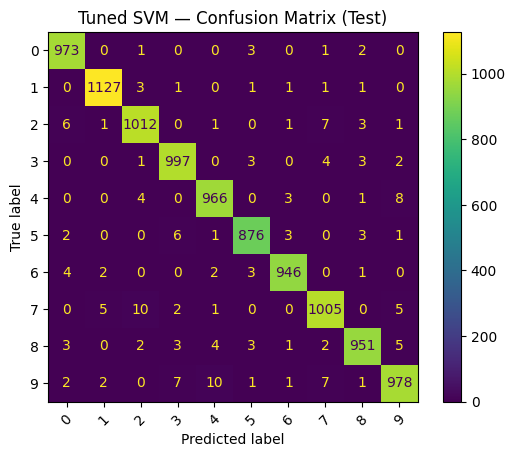

In [ ]:
svm_grid = {
    'C': [0.5, 1.0, 2.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

gs_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

gs_svm.fit(X_train_flat, y_train)
print("Best params (SVM):", gs_svm.best_params_)
print("Best CV accuracy:", gs_svm.best_score_)

svm_best = gs_svm.best_estimator_

y_tr_pred = svm_best.predict(X_train_flat)
print("\nTuned SVM — Training")
print("Accuracy:", round(accuracy_score(y_train, y_tr_pred), 4))
print("Precision:", round(precision_score(y_train, y_tr_pred, average='weighted', zero_division=0), 4))
print("Recall:", round(recall_score(y_train, y_tr_pred, average='weighted', zero_division=0), 4))
print("F1-score:", round(f1_score(y_train, y_tr_pred, average='weighted'), 4))

y_te_pred = svm_best.predict(X_test_flat)
print("\nTuned SVM — Test")
print("Accuracy:", round(accuracy_score(y_test, y_te_pred), 4))
print("Precision:", round(precision_score(y_test, y_te_pred, average='weighted', zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_te_pred, average='weighted', zero_division=0), 4))
print("F1-score:", round(f1_score(y_test, y_te_pred, average='weighted'), 4))

cm = confusion_matrix(y_test, y_te_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
plt.title("Tuned SVM — Confusion Matrix (Test)")
plt.show()

### GridSearchCV for Decision Tree

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (DT): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.8694666666666667

Tuned Decision Tree — Training
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Tuned Decision Tree — Test
Accuracy: 0.8857
Precision: 0.8858
Recall: 0.8857
F1-score: 0.8857


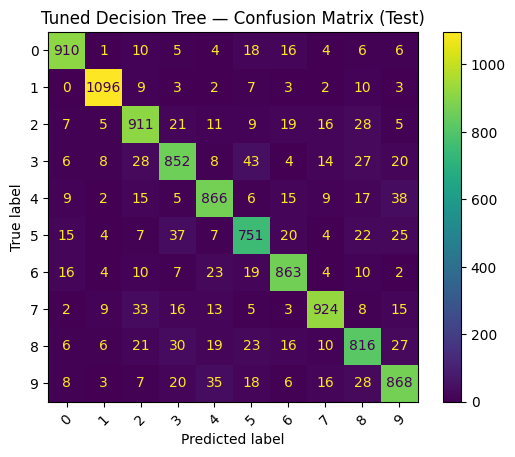

In [ ]:
dt_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gs_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

gs_dt.fit(X_train_flat, y_train)
print("Best params (DT):", gs_dt.best_params_)
print("Best CV accuracy:", gs_dt.best_score_)

dt_best = gs_dt.best_estimator_

y_tr_pred = dt_best.predict(X_train_flat)
print("\nTuned Decision Tree — Training")
print("Accuracy:", round(accuracy_score(y_train, y_tr_pred), 4))
print("Precision:", round(precision_score(y_train, y_tr_pred, average='weighted', zero_division=0), 4))
print("Recall:", round(recall_score(y_train, y_tr_pred, average='weighted', zero_division=0), 4))
print("F1-score:", round(f1_score(y_train, y_tr_pred, average='weighted'), 4))

y_te_pred = dt_best.predict(X_test_flat)
print("\nTuned Decision Tree — Test")
print("Accuracy:", round(accuracy_score(y_test, y_te_pred), 4))
print("Precision:", round(precision_score(y_test, y_te_pred, average='weighted', zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_te_pred, average='weighted', zero_division=0), 4))
print("F1-score:", round(f1_score(y_test, y_te_pred, average='weighted'), 4))

cm = confusion_matrix(y_test, y_te_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
plt.title("Tuned Decision Tree — Confusion Matrix (Test)")
plt.show()


### Training Evaluation and Testing evaluation

Logistic Regression (tuned) — Training
Accuracy:  0.9324
Precision: 0.9322
Recall:    0.9324
F1-score:  0.9323
-----------------------------------


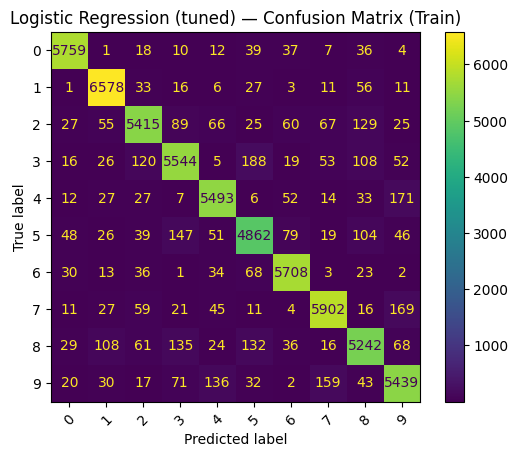

SVM (tuned) — Training
Accuracy:  0.9957
Precision: 0.9957
Recall:    0.9957
F1-score:  0.9957
-----------------------------------


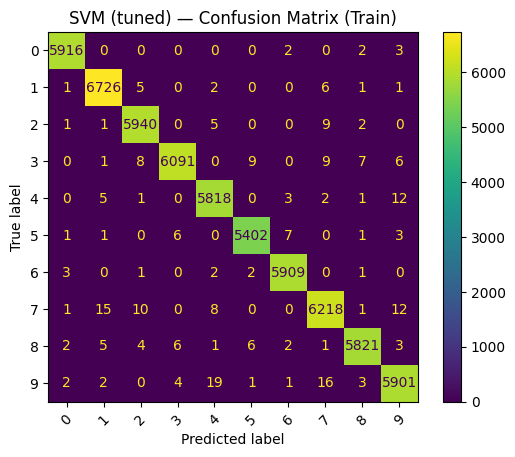

Decision Tree (tuned) — Training
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
-----------------------------------


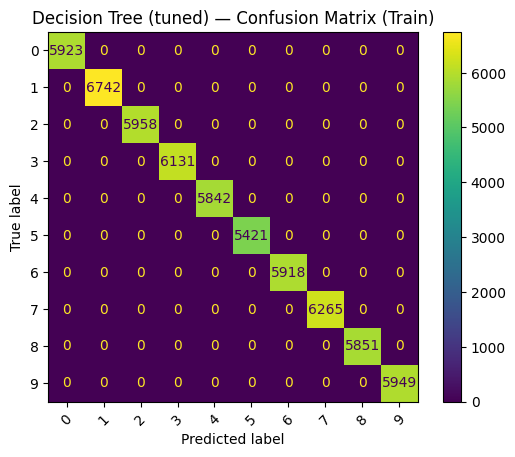

In [ ]:
tuned = {
    "Logistic Regression (tuned)": lr_best,
    "SVM (tuned)": svm_best,
    "Decision Tree (tuned)": dt_best
}

for name, model in tuned.items():
    y_pred = model.predict(X_train_flat)
    acc  = accuracy_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_train, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_train, y_pred, average='weighted')

    print(name, "— Training")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("-"*35)

    cm = confusion_matrix(y_train, y_pred)
    ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix (Train)")
    plt.show()


Logistic Regression (tuned) — Test
Accuracy:  0.9259
Precision: 0.9258
Recall:    0.9259
F1-score:  0.9257
-----------------------------------


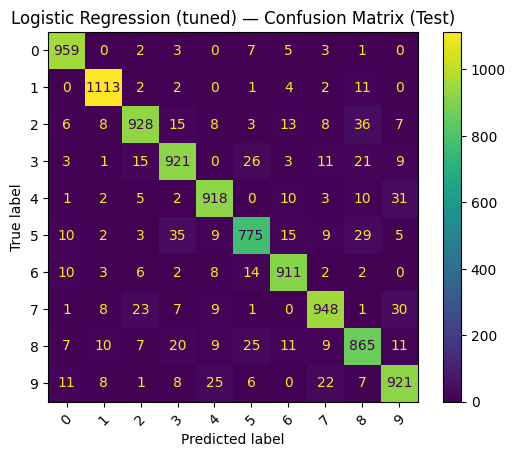

SVM (tuned) — Test
Accuracy:  0.9831
Precision: 0.9831
Recall:    0.9831
F1-score:  0.9831
-----------------------------------


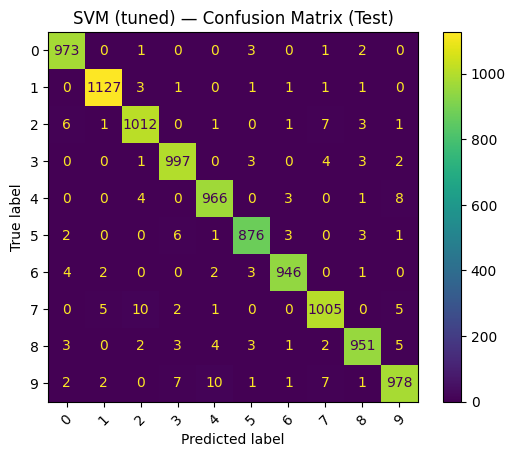

Decision Tree (tuned) — Test
Accuracy:  0.8857
Precision: 0.8858
Recall:    0.8857
F1-score:  0.8857
-----------------------------------


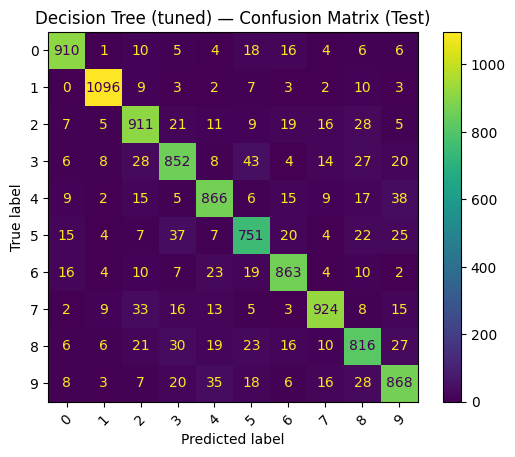

In [ ]:
tuned = {
    "Logistic Regression (tuned)": lr_best,
    "SVM (tuned)": svm_best,
    "Decision Tree (tuned)": dt_best
}

for name, model in tuned.items():
    y_pred = model.predict(X_test_flat)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted')

    print(name, "— Test")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("-"*35)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(values_format='d', xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix (Test)")
    plt.show()


In [ ]:
def bootstrap_eval(model, X, y, n_iterations=100):
    accs, precs, recs, f1s = [], [], [], []
    for _ in range(n_iterations):
        X_res, y_res = resample(X, y, replace=True)
        y_hat = model.predict(X_res)
        accs.append(accuracy_score(y_res, y_hat))
        precs.append(precision_score(y_res, y_hat, average='weighted', zero_division=0))
        recs.append(recall_score(y_res, y_hat, average='weighted', zero_division=0))
        f1s.append(f1_score(y_res, y_hat, average='weighted'))
    def stats(a):
        a = np.array(a)
        return a.mean(), a.std(), np.percentile(a, 2.5), np.percentile(a, 97.5)
    return {
        'accuracy': stats(accs),
        'precision': stats(precs),
        'recall': stats(recs),
        'f1': stats(f1s)
    }

bootstrap_results = {}
for name, model in tuned.items():
    print(f"\nBootstrapping (n=100) — {name}")
    res = bootstrap_eval(model, X_test_flat, y_test, n_iterations=100)
    bootstrap_results[name] = res
    for metric, (mean_, std_, lo, hi) in res.items():
        print(f"{metric.upper():<9}: {mean_:.4f} ± {std_:.4f} | 95% CI [{lo:.4f}, {hi:.4f}]")



Bootstrapping (n=100) — Logistic Regression (tuned)
ACCURACY : 0.9257 ± 0.0024 | 95% CI [0.9207, 0.9300]
PRECISION: 0.9256 ± 0.0025 | 95% CI [0.9206, 0.9300]
RECALL   : 0.9257 ± 0.0024 | 95% CI [0.9207, 0.9300]
F1       : 0.9255 ± 0.0025 | 95% CI [0.9206, 0.9299]

Bootstrapping (n=100) — SVM (tuned)


### Model Comparison

In [ ]:
tuned = {
    "Logistic Regression (tuned)": lr_best,
    "SVM (tuned)": svm_best,
    "Decision Tree (tuned)": dt_best
}

rows = []
for name, model in tuned.items():
    ytr = model.predict(X_train_flat)
    yte = model.predict(X_test_flat)

    tr_acc = accuracy_score(y_train, ytr)
    te_acc = accuracy_score(y_test, yte)
    tr_f1  = f1_score(y_train, ytr, average='weighted')
    te_f1  = f1_score(y_test, yte, average='weighted')

    rows.append({
        "Model": name,
        "Train Accuracy": round(tr_acc, 4),
        "Test Accuracy": round(te_acc, 4),
        "Accuracy Gap": round(tr_acc - te_acc, 4),
        "Train F1": round(tr_f1, 4),
        "Test F1": round(te_f1, 4),
        "F1 Gap": round(tr_f1 - te_f1, 4)
    })

comparison_df = pd.DataFrame(rows).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
comparison_df


### Tasrif Nur Himel

### Tasrif Nur Himel